# CodeLab 2 - Regression models for load forecast

In this CodeLab, provided data set contains historical Netherland's hourly demand profile and day ahead forecast collected from Entso-E and weather data collected from NASA Merra. 

In [269]:
!pip install scikit-learn

In [270]:
#Import Libraries
import numpy as np 
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.svm import SVR
import time
import pickle

# Task 1: Load energy data 

“Data.csv” file contains all related information and can be loaded/read using Pandas library. Pandas library is a useful library for investigating and processing datasets. 

<br>-Load the dataset using “pandas.read_csv” function.

In [271]:
#Load input csv file with pandas
Input = pd.read_csv('data.csv', delimiter=';') #01.01.2019-Tuesday 

In [272]:
Input

,day,month,hours,precipitation,temperature,irradiance_surface,irradiance_toa,snowfall,snow_mass,cloud_cover,air_density,Forecast load (MW),Actual load (MW),Positive imbalance price (Eur/MWh),Negative imbalance price (Eur/MWh)
0,1,1,0,0.0349,7.196,0.0,0.0,0.0000,0.0000,0.9970,1.2738,12390.75,11284.75,14.50,38.90
1,1,1,1,0.0373,7.278,0.0,0.0,0.0000,0.0000,0.9981,1.2730,11810.00,11193.75,0.00,36.48
2,1,1,2,0.0459,7.364,0.0,0.0,0.0000,0.0000,0.9973,1.2720,11410.50,10933.25,29.30,34.19
3,1,1,3,0.0528,7.415,0.0,0.0,0.0000,0.0000,0.9907,1.2711,11309.00,10666.75,21.66,27.21
4,1,1,4,0.0628,7.503,0.0,0.0,0.0000,0.0000,0.9665,1.2699,11420.25,10413.25,0.00,30.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,31,12,19,0.0104,3.090,0.0,0.0,0.0000,0.0000,0.8590,1.3002,12945.50,14247.75,0.00,12.22
8756,31,12,20,0.0154,2.789,0.0,0.0,0.0000,0.0000,0.8434,1.3037,12379.75,13517.25,0.00,24.20
8757,31,12,21,0.0152,2.327,0.0,0.0,0.0000,0.0000,0.8357,1.3064,11820.25,12799.25,17.03,17.50
8758,31,12,22,0.0143,1.858,0.0,0.0,0.0000,0.0000,0.8775,1.3085,11163.00,12064.25,0.00,2.51


-Find the date and hour that corresponds to the maximum electricity consumption.
<br> -Plot the following variables for the entire day (00:00-23:00) of the maximum consumption in subplots. Subplot 1: Actual load (MW) and Forecasted load (MW), subplot 2: temperature, subplot 3: irradiance_surface, and subplot 4: snowfall. The X-axis of all subplots is the hour of the day.
<br>Hint: Dataframe.columns print out the column names of the data frame.

In [273]:
maxx = Input['Actual load (MW)'].max()
max_index = Input['Actual load (MW)'].idxmax()
#print(Input.loc[max_index])

max_day = Input.loc[max_index, 'day']
max_month = Input.loc[max_index, 'month']
max_hour = Input.loc[max_index, 'hours']
Data_max_day = Input[(Input['day'] == max_day) & (Input['month']  == max_month)]
#print(Data_max_day)

print("The date for maximum electricity consumption: {}/{}".format(max_day, max_month))
print("The hour for maximum electricity consumption: ", max_hour)

The date for maximum electricity consumption: 22/1
The hour for maximum electricity consumption:  17


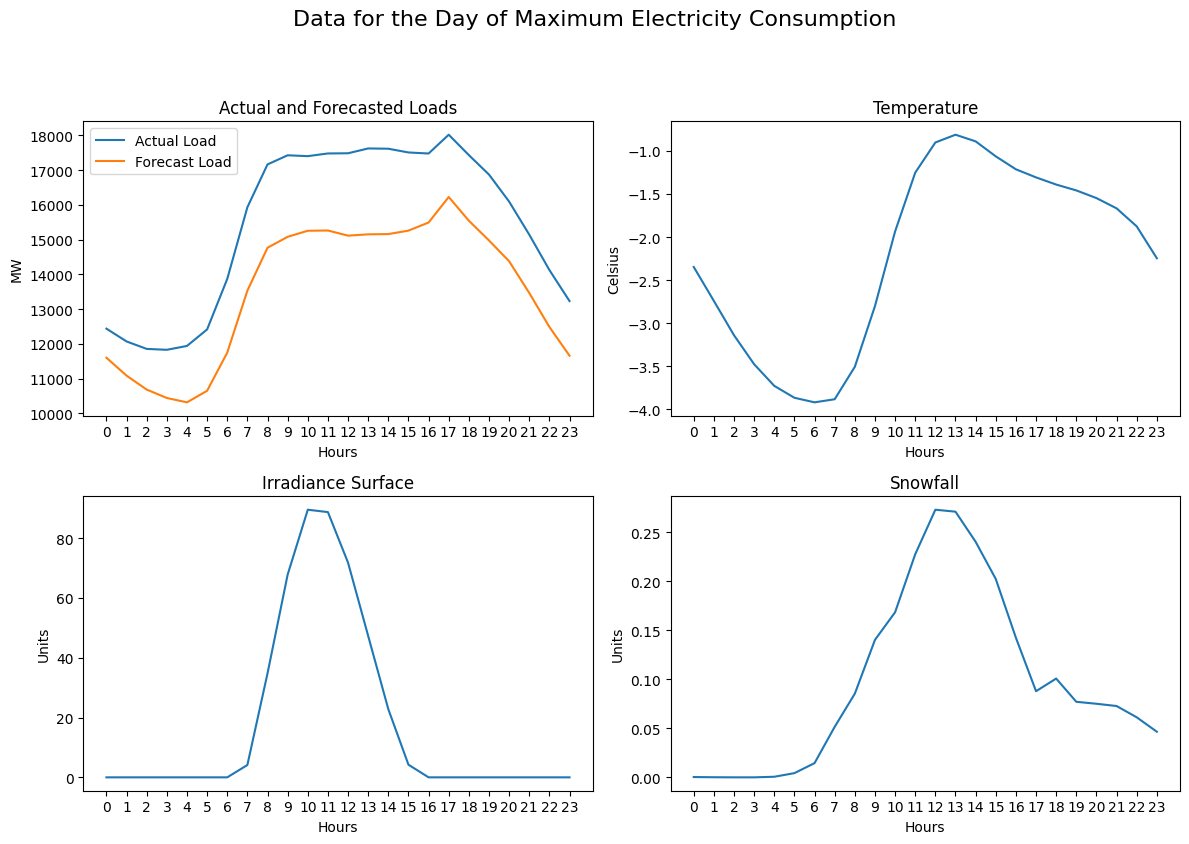

In [274]:
actual_load_max_day = Data_max_day['Actual load (MW)']
forecasted_load_max_day = Data_max_day['Forecast load (MW)']
temperature_max_day = Data_max_day['temperature']
irradiance_surface_max_day = Data_max_day['irradiance_surface']
snowfall_max_day = Data_max_day['snowfall']
hours_max_day = Data_max_day['hours']

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Data for the Day of Maximum Electricity Consumption', fontsize=16, y=1.05)

# Plotting for first subplot
axs[0, 0].plot(hours_max_day, actual_load_max_day, label='Actual Load')
axs[0, 0].plot(hours_max_day, forecasted_load_max_day, label='Forecast Load')
axs[0, 0].set_xlabel("Hours")
axs[0, 0].set_ylabel("MW")
axs[0, 0].legend()
axs[0, 0].set_xticks(hours_max_day)
axs[0, 0].set_title('Actual and Forecasted Loads')

# Plotting for second subplot
axs[0, 1].plot(hours_max_day, temperature_max_day)
axs[0, 1].set_xlabel("Hours")
axs[0, 1].set_ylabel("Celsius")
axs[0, 1].set_xticks(hours_max_day)
axs[0, 1].set_title('Temperature')

# Plotting for third subplot
axs[1, 0].plot(hours_max_day, irradiance_surface_max_day)
axs[1, 0].set_xlabel("Hours")
axs[1, 0].set_ylabel("Units")
axs[1, 0].set_xticks(hours_max_day)
axs[1, 0].set_title('Irradiance Surface')

# Plotting for fourth subplot
axs[1, 1].plot(hours_max_day, snowfall_max_day)
axs[1, 1].set_xlabel("Hours")
axs[1, 1].set_ylabel("Units")
axs[1, 1].set_xticks(hours_max_day)
axs[1, 1].set_title('Snowfall')

plt.tight_layout()
plt.savefig("task1_1.png")
plt.show()

The process of training a machine learning model relies on data or features. Properly prepared features are essential for learning. Real life applications requires knowledge on data and models, this process is called as feature engineering which will be covered in CodeLab 4. In this CodeLab, you will work on these 3 different feature matrices X_1, X_2, and X_3. Use the following pickle command to load the dictionary "D" which contains features and the target variable. 
<br> -Print the keys of dictionary with ".keys()" function.
<br> -Extract the contents of the dictionary in following variables X_1, X_2, C, and y.


In [275]:
D = pickle.load(open('file.pkl', 'rb'))
#print(D)

print('Keys:',D.keys()) #prints keys

Keys: dict_keys(['Feature1', 'Feature2', 'Categorical', 'Target'])


In [276]:
y = D["Target"]
#print('Y: ', y)
X_1 = D["Feature1"]
#print('X_1: ', X_1)
X_2 = D["Feature2"]
#print('X_2: ',X_2)
C = D["Categorical"]
#print('C: ', C)

"Feature1" (X_1) contains previous load demand and weather predictions. "Feature2" (X_2) has the full content of "Feature1" and the load forecast values from Entso-E. "Categorical" (C) features represent the categorical time element of the data in a one-hot encoded way. For example, C[i]=[100001100] represents data is taken from a weekend in the fall season and a daytime (07:00-16:00) load. Details regarding one-hot encoding and the structure of C is included in the bonus task of CodeLab. "Target" contains the target variable (y) of the ML model. Further details are explained in the PDF document. 
<br> -Calculate the sparsity of X_1, X_2, and C. 

In [277]:
# Function to calculate sparsity
def calculate_sparsity(matrix):
    total_elements = matrix.size
    zero_elements = np.count_nonzero(matrix == 0)
    sparsity = zero_elements / total_elements
    return sparsity

In [278]:
# Calculate sparsity for X_1, X_2, and C
sparsity_X1 = calculate_sparsity(X_1)
sparsity_X2 = calculate_sparsity(X_2)
sparsity_C = calculate_sparsity(C)

#print(f"Sparsity of X_1: {sparsity_X_1:.2%}")
#print(f"Sparsity of X_2: {sparsity_X_2:.2%}")
#print(f"Sparsity of C: {sparsity_C:.2%}")

print('Sparsity of X_1: ', sparsity_X1)
print('Sparsity of X_2: ', sparsity_X2)
print('Sparsity of C: ', sparsity_C)

Sparsity of X_1:  0.2159880389628993
Sparsity of X_2:  0.20056032189412076
Sparsity of C:  0.6666666666666666


#### Questions
<br>1)	What is the difference between the forecasted and actual loads at the hour of the maximum consumption?
<br>2)  What do you observe from the generated subplots? 
<br>3)  Which features in the subplots might be good features for the machine learning model and why?
<br>4)  Calculate and write the sparsity of C. 
<br>5)  Explain why to use encoding instead numeric date values in a regression problem.
<br>6)  Explain why we need the time information for the load forecast problem.
<br>7)  Why is it important to calculate sparsity? What does it mean to have a high/low sparsity and how it would affect the regression?

In [279]:
#Question 1
Data_max_day_hour = Input[(Input['day'] == max_day) & (Input['month']  == max_month) & (Input['hours']  == max_hour)]
#print(Data_max_day_hour)
actual_load_max_day_hour = Data_max_day_hour['Actual load (MW)']
#print(actual_load_max_day_hour)
forecasted_load_max_day_hour = Data_max_day_hour['Forecast load (MW)']
#print(forecasted_load_max_day_hour)
difference = abs(actual_load_max_day_hour-forecasted_load_max_day_hour)
#print(difference)
print("Difference between the forecasted and actual loads at the hour of the maximum consumption: {} MW".format(difference.values[0]))

#Question 4
print('Sparsity of C: ', sparsity_C)

Difference between the forecasted and actual loads at the hour of the maximum consumption: 1792.5 MW
Sparsity of C:  0.6666666666666666


# Task 2: Process data and prepare for machine learning algorithms

In this task, you will generate all feature sets and standardize or scale the data for the training process. 

<br>The standardization process is essential for many machine learning models. For instance, many algorithms (such as the RBF kernel of Support Vector Machines) assume that all features are centered around 0 and have variance in the same order. If a feature has a variance that is orders of magnitude larger than others, it might dominate and make the estimator unable to learn from other features correctly as expected [Sklearn StandardScaler-https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html] . 

<br>Features are standardized by removing the mean and scaling to unit variance. This process is called standard scaling or z normalization. 

<br> z = (x-u)/s where u is the mean of feature and s is the standard deviation.

<br> -Use sklearn StandardScaler to scale X_1.
<br> -Define a new scaler to scale X_2.
<br> -Concatenate categorical variable matrix C to scaled X_2 which will generate the third feature set X_3. 
<br> X_1 = [Weather(t), Historical_demand(t-x)], X_2 = [X_1, Forecast], X_3 = [X_2scaled, C]

In [280]:
#Feature scaling
#Step 1
scaler_X1 = StandardScaler()
X_1_scaled = scaler_X1.fit_transform(X_1) #data being standardized means fitting the scaler to the data and transforming the data 
print(f"X_1 scaled shape: {X_1_scaled.shape}")
#Step 2
scaler_X2 = StandardScaler()
X_2_scaled = scaler_X2.fit_transform(X_2)
print(f"X_2 scaled shape: {X_2_scaled.shape}")
#Step 3
X_3 = np.hstack((X_2_scaled, C))
print(f"C shape: {C.shape}")
print(f"X_3 shape: {X_3.shape}")

X_1 scaled shape: (8592, 13)
X_2 scaled shape: (8592, 14)
C shape: (8592, 9)
X_3 shape: (8592, 23)


The dataset must be split into training and test sets. 25% of the data will be used for test proposes. To generate reproducible results, please use the given Shuffle_state variable as a random state of the splitter function. Note: When you call the Shuffle_state, y_train, and y_test (target variables) from different splits will be the same.
<br>-Split X_1, X_2 and X_3 using Sklearn train_test_split() function into 3 training and 3 test data
<br>-Print out the mean of X_1, scaled X_1, training data X_1 (scaled), and test data X_1 (scaled).

In [281]:
#Train test split
Test_ratio = 0.25
Shuffle_state = 4720

# Split X_1 (scaled versions)
X_train1, X_test1, y_train, y_test = train_test_split(X_1_scaled, y, test_size=Test_ratio, random_state=Shuffle_state)

# Split X_2 (scaled versions)
X_train2, X_test2, y_train, y_test = train_test_split(X_2_scaled, y, test_size=Test_ratio, random_state=Shuffle_state)

# Split X_3 (concatenated with categorical features)
X_train3, X_test3, y_train, y_test = train_test_split(X_3, y, test_size=Test_ratio, random_state=Shuffle_state)

# To avoid data leakage, fit the scaler only on the training data and transform the test data with it
# Refit the scaler on training data (scaling should be based only on training data for real models)
# Transform the test data using the scaler fitted on the training data
#X_1_scaler_train = StandardScaler()
#X1_train_scaled = X_1_scaler_train.fit_transform(X_train1)
#X1_test_scaled = X_1_scaler_train.transform(X_test1)

print("Mean of X_1 = %.3f"% np.mean(X_1))
print("Mean of scaled X_1 = %.3f"% np.mean(X_1_scaled))
print("Mean of scaled X_train1 = %.3f"% np.mean(X_train1))
print("Mean of scaled X_test1 = %.3f" % np.mean(X_test1))
#print("Mean of scaled X_train1 = %.3f"% np.mean(X1_train_scaled))
#print("Mean of scaled X_test1 = %.3f" % np.mean(X1_test_scaled))

Mean of X_1 = 5030.273
Mean of scaled X_1 = 0.000
Mean of scaled X_train1 = -0.001
Mean of scaled X_test1 = 0.004


#### Questions
<br> 1) Why do you use 2 different scalers? What happens if the first one used for to scale X_2 as well?
<br> 2) Why categorical variables are not scaled?

# Task 3: Training and evaluation of linear regressors

In this CodeLab, different regression models are implemented. Using linear regression models, you should identify the best feature set to investigate further. After the most appropriate feature set is identified, regularization on linear regression is investigated through Ridge and Lasso models.

#### Linear Regression:
-Construct and train three linear regression models using feature sets X_1, X_2 and X_3.
<br> -Define a function test_mymodel(model,X_test,y_test) to evaluate the model performance. Function takes model, test features and test target variable (label), output is R2 score and MSE. 
<br> -Evaluate models with test_mymodel and record the output.

In [282]:
#Linear regression models for the feature sets
lin_reg_1 = LinearRegression() # Model for feature set X_1
lin_reg_2 = LinearRegression() # Model for feature set X_2
lin_reg_3 = LinearRegression() # Model for feature set X_3

# Fit the models to the training sets
lin_reg_1.fit(X_train1, y_train)
lin_reg_2.fit(X_train2, y_train)
lin_reg_3.fit(X_train3, y_train)

LinearRegression()

In [283]:
#Model evaluation function
def test_mymodel(model,X_test,y_test):
    y_prediction = model.predict(X_test) # Use X_test to predict y_test as y_prediction
    MSE = mean_squared_error(y_test, y_prediction)
    R2 = r2_score(y_test, y_prediction)
    return MSE,R2

In [284]:
#Comparison of different feature sets

MSE=[]; R2=[] #initialization

MSE.append(test_mymodel(lin_reg_1, X_test1, y_test)[0])
MSE.append(test_mymodel(lin_reg_2, X_test2, y_test)[0])
MSE.append(test_mymodel(lin_reg_3, X_test3, y_test)[0])

formatted_MSE = ", ".join([f"{mse:.2f}" for mse in MSE])
print(f"MSE scores of linear regressors: {formatted_MSE}")
#print("MSE scores of linear regressors: "+str(MSE))

R2.append(test_mymodel(lin_reg_1, X_test1, y_test)[1])
R2.append(test_mymodel(lin_reg_2, X_test2, y_test)[1])
R2.append(test_mymodel(lin_reg_3, X_test3, y_test)[1])

formatted_R2 = ", ".join([f"{r2:.16f}" for r2 in R2])
print(f"R2 scores of linear regressors: {formatted_R2}")
#print("R2 scores of linear regressors: " +str(R2))

MSE scores of linear regressors: 928883.96, 622490.38, 421009.82
R2 scores of linear regressors: 0.7511760412272825, 0.8332509462161521, 0.8872223706802830


In [285]:
# Extra: Check the range and mean of y_test
y_test_range = np.max(y_test) - np.min(y_test)
y_test_mean = np.mean(y_test)
y_test_var = np.var(y_test)

print(f"Range of y_test: {y_test_range}")
print(f"Mean of y_test: {y_test_mean}")
print(f"Variance of y_test: {y_test_var}")

Range of y_test: 9031.0
Mean of y_test: 13008.709846368714
Variance of y_test: 3733096.9483702276


 -Plot  2 bar graphs for R2 and MSE of all linear regression models (Hint: use plt.ylim() to adjust limits for better visuals). 
<br> -Plot all predictions and test data together for the first 64 hours or between [0:63] sample points.
<br> -Print out the weigths of the best model and find the absolute maximum difference between weights. 

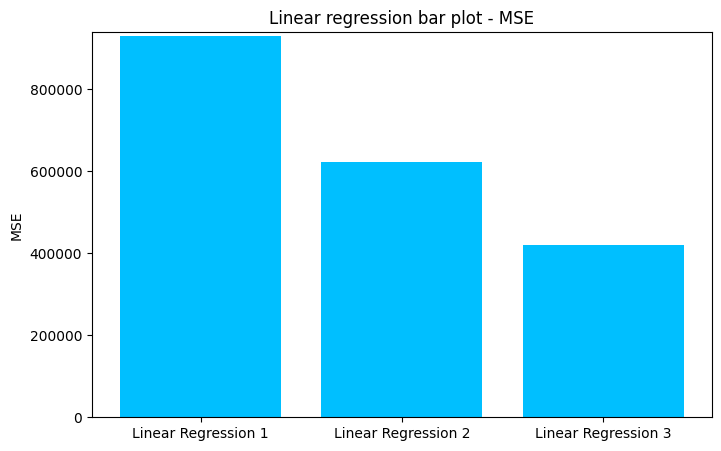

In [286]:
#MSE bar plot for linear regression 
low = 0
high =  max(MSE) * 1.01
name = ["Linear Regression 1", "Linear Regression 2", "Linear Regression 3"]
plt.figure(figsize=(8, 5))
plt.ylabel('MSE')
plt.title("Linear regression bar plot - MSE" )
plt.bar(name, MSE,color='deepskyblue')
plt.ylim(low, high);
plt.savefig("task3_1mse.png")

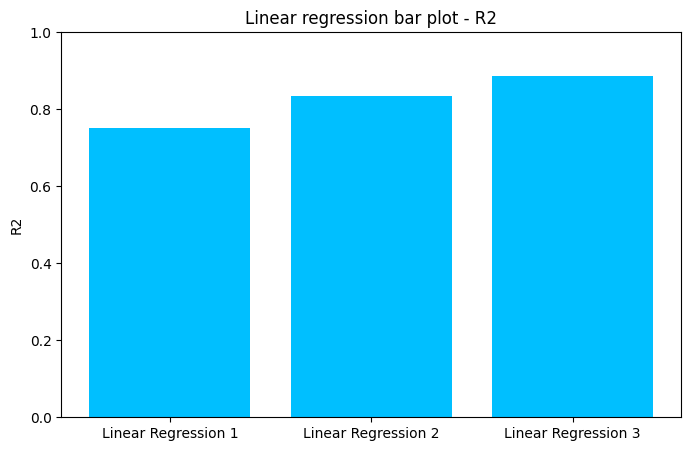

In [287]:
#R2 bar plot for linear regression 
low = 0
high = 1
name = ["Linear Regression 1", "Linear Regression 2", "Linear Regression 3"]
plt.figure(figsize=(8, 5))
plt.ylabel('R2')
plt.title("Linear regression bar plot - R2" )
plt.bar(name, R2,color='deepskyblue')
plt.ylim(low, high);
plt.savefig("task3_1rsquare.png")

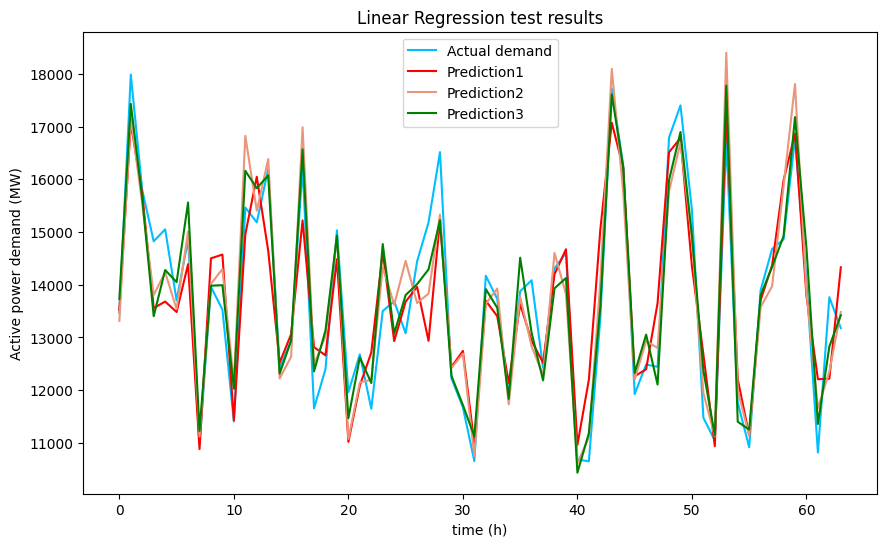

In [288]:
#Time series plot of prediction 
lin_predict_1 = lin_reg_1.predict(X_test1) 
lin_predict_2 = lin_reg_2.predict(X_test2)
lin_predict_3 = lin_reg_3.predict(X_test3)
plt.figure(figsize=(10.24,6.00))
plt.plot(y_test[:64],c='deepskyblue',label='Actual demand')
plt.plot(lin_predict_1[:64],c='r',label='Prediction1')
plt.plot(lin_predict_2[:64],c='darksalmon',label='Prediction2')
plt.plot(lin_predict_3[:64],c='g',label='Prediction3')

plt.xlabel('time (h)') 
plt.ylabel('Active power demand (MW)')
plt.title("Linear Regression test results")
plt.legend()
plt.savefig("task3_1dataprediction.png")

In [289]:
import itertools

In [290]:
# Print coefficients
best_model = lin_reg_3  # Assuming the third model is the best based on R²
coefficients = best_model.coef_  # Coefficients of the best model

print(f"Coefficients of the best model: {coefficients}")

# Calculate and print the absolute maximum difference between the coefficients
# Calculate the absolute differences between all pairs of coefficients
abs_diff_pairs = [abs(a - b) for a, b in itertools.combinations(coefficients, 2)]

# Find the maximum absolute difference
absolute_max_diff = max(abs_diff_pairs)
print("\nAbsolute max difference = %.2f" % absolute_max_diff)

Coefficients of the best model: [   17.94423218  -326.42386824  -481.63566056   548.67731475
    25.5450198    -19.84711394    21.16472399  -132.01353121
  1013.44354774 -1043.45228794   165.50478211    96.80661346
   520.20716573   671.84417051  -425.22014807   425.22014807
  -196.66521128   -62.39361706   160.41813932    98.64068903
   291.96236016   525.61856801  -817.58092816]

Absolute max difference = 2056.90


In [332]:
maxx = max(coefficients)
print(maxx)
minn = min(coefficients)
print(maxx-minn)

1013.4435477369773
2056.8958356760777


#### Ridge & Lasso Regression:
Ridge & Lasso regression models are modified forms of linear regression. The complexity parameter alpha controls the complexity of the model. Adjust the alpha parameter to obtain the best results. Although alpha in both models adjusts the regularization in the optimization problem, their mathematical interpretations are different so same alpha values will have different effects in training. 
<br> -Train ridge and lasso regression models with alpha=0.1, using the best performing feature set in linear regression.
<br> -Test both models with test_mymodel() and record R2 and MSE values.
<br> -Train and test both models again with varying alpha values starting from 0.0005 to 1.0 with a step size equal to 0.005. Record R2 and MSE at each step.
<br> -Plot "alpha vs MSE" and "alpha vs R2" to find the best performing regularization parameter alpha and its effect on prediction.

Ridge and Lasso models construct an optimization problem, therefore for numerical stability we have scaled the target variable as well with the following code block. Please use the new y_train_s and y_test_s to fit and test models. Otherwise, convergence problems might be observed.

In [291]:
u = np.mean(y_train)
s = np.std(y_train)
y_train_s = (y_train-u)/s
y_test_s = (y_test-u)/s

In [292]:
#Ridge & Lasso Regression
Rid_reg= Ridge(alpha=0.1)
Las_reg = Lasso(alpha=0.1)

#Using the best-performing feature set in the previous linear regression task which was lin_reg_3
Rid_reg.fit(X_train3, y_train_s)  # X_train3 as the best feature set
Las_reg.fit(X_train3, y_train_s)

MSE_rid, R2_rid= test_mymodel(Rid_reg, X_test3, y_test_s)
MSE_las, R2_las = test_mymodel(Las_reg, X_test3, y_test_s)
print("MSE scores of ridge regressor: %.2f"%(MSE_rid))
print("MSE scores of lasso regressor: %.2f"%(MSE_las))
print("R2 scores of ridge regressors: %.5f"%(R2_rid))
print("R2 scores of lasso regressors: %.5f"%(R2_las))

MSE scores of ridge regressor: 0.11
MSE scores of lasso regressor: 0.23
R2 scores of ridge regressors: 0.88722
R2 scores of lasso regressors: 0.76927


In [293]:
#Effect of alpha
alpha_records = np.arange(0.005, 1.05, 0.005)  # Alpha values from 0.005 to 1.0 with step size 0.005
MSE_record_ridge = []
MSE_record_lasso = []
R2_record_ridge = []
R2_record_lasso = []
for i in alpha_records:
    # Initialize Ridge and Lasso models with varying alpha
    model_ridge = Ridge(alpha=i)
    model_lasso = Lasso(alpha=i)
    # Fit the models to the scaled training data
    model_ridge.fit(X_train3, y_train_s)
    model_lasso.fit(X_train3, y_train_s)
    # Evaluate models using the test set
    MSE_rid, R2_rid = test_mymodel(model_ridge, X_test3, y_test_s)
    MSE_las, R2_las = test_mymodel(model_lasso, X_test3, y_test_s)
    # Store the results
    MSE_record_ridge.append(MSE_rid)
    MSE_record_lasso.append(MSE_las)
    R2_record_ridge.append(R2_rid)
    R2_record_lasso.append(R2_las)

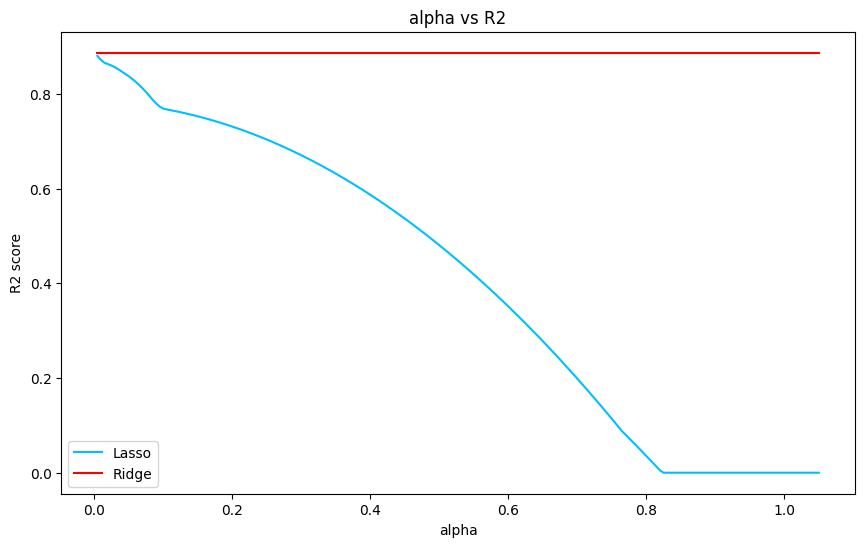

In [294]:
#Alpha vs R2
plt.figure(figsize=(10.24,6.00))
plt.plot(alpha_records, R2_record_lasso,c='deepskyblue',label='Lasso')
plt.plot(alpha_records, R2_record_ridge,c='r',label='Ridge')
plt.xlabel('alpha') 
plt.ylabel('R2 score')
plt.title("alpha vs R2")
plt.legend()
plt.savefig("task3_2r2.png")

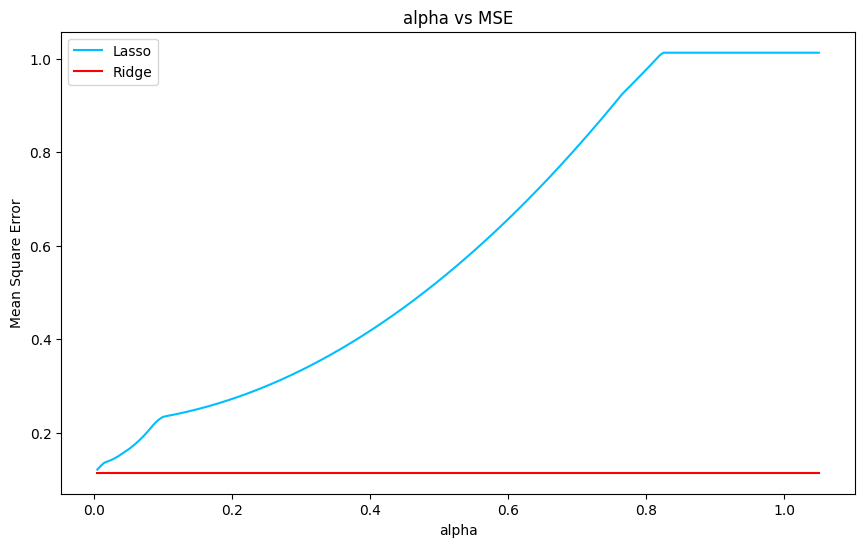

In [295]:
#Alpha vs MSE
plt.figure(figsize=(10.24,6.00))
plt.plot(alpha_records, MSE_record_lasso,c='deepskyblue',label='Lasso')
plt.plot(alpha_records, MSE_record_ridge,c='r',label='Ridge')
plt.xlabel('alpha') 
plt.ylabel('Mean Square Error')
plt.title("alpha vs MSE")
plt.legend()
plt.savefig("task3_2mse.png")

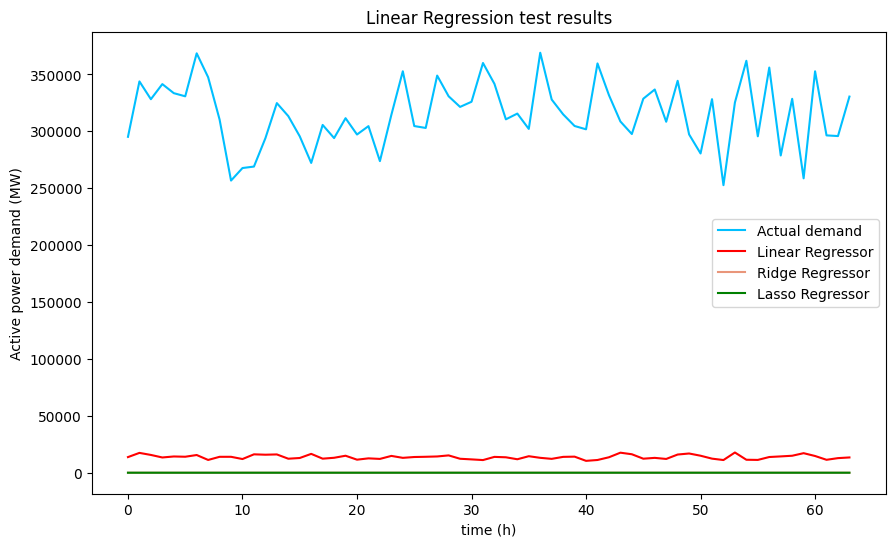

In [333]:
#Time series plot of prediction 
lin_predict_3 = lin_reg_3.predict(X_test3) 
rid_predict = Rid_reg.predict(X_test3)
las_predict = Las_reg.predict(X_test3)
plt.figure(figsize=(10.24,6.00))
plt.plot(y_test[:64],c='deepskyblue',label='Actual demand')
plt.plot(lin_predict_3[:64],c='r',label='Linear Regressor')
plt.plot(rid_predict[:64],c='darksalmon',label='Ridge Regressor')
plt.plot(las_predict[:64],c='g',label='Lasso Regressor')

plt.xlabel('time (h)') 
plt.ylabel('Active power demand (MW)')
plt.title("Linear Regression test results")
plt.legend()
plt.savefig("task3_1datapredictionsss.png")

#### Questions
<br> 1)	Record R2 and MSE scores of linear regression models, compare and comment on the results.
<br> 2)	What does MSE represent for the linear regression problem in this CodeLab?
<br> 3)	Which feature set gives the best prediction capability? 
<br> 4)	What is the absolute difference between the maximum and minimum weights of the best performing model? 
<br> 5)	What do weights correspond to in a linear regression?
<br> 6)	What is the role of alpha in Ridge and Lasso models?
<br> 7) Why is the MSE of Ridge & Lasso a thousand times smaller than the linear regression?
<br> 8)	Compare the results of regularized models with previous linear regressors.
<br> 9) What is the value of alpha that gives the smallest error in the test set?

# Task 4: Support Vector Machine

Support vector machines (SVMs) are supervised machine learning methods used for classification, regression and outliers detection.  This technique will be introduced in week 3. However, now you can treat it as a black box and try to play with it. If you are eager to find out what it is and how it works, this link may help you.

https://medium.com/cube-dev/support-vector-machines-tutorial-c1618e635e93


In this practicum SVM is investigated with different parameters and kernels. Kernels are decision functions which have been applied to transform the feature space into higher dimensions. Nonlinear relationships between features can be found in high dimensional space. 
<br> Compared to linear models construction of SVM is much more expensive. Time library can be utilized the measure the training time of SVM. For this task, please use again the scaled target variables for numerical stability. 
<br> -Construct a linear SVM regressor with default parameters and record R2, MSE and training time.
<br> Note: Add maximum iteration as 1e6 or 1e7 inside the model definition to avoid long training times.

In [296]:
#Time measurement 
#Put the start value at the beginning of the cell and put stop value at the end of the cell.
#start = time.time()
#stop = time.time()
#print("Required Time= "+str(stop-start))

In [297]:
#Linear SVM
start = time.time()
svm_lin = SVR(kernel='linear', max_iter=int(1e6)) 
svm_lin.fit(X_train3, y_train_s) 
MSE_svmlin, R2_svmlin= test_mymodel(svm_lin, X_test3, y_test_s)
print("MSE scores of linear SVM: "+str(MSE_svmlin))
print("R2 scores of linear SVM: "+str(R2_svmlin))
stop = time.time()
print("Required Time for linear SVM seconds= "+str(stop-start)+" seconds")

MSE scores of linear SVM: 0.11654203034659039
R2 scores of linear SVM: 0.8849485318868058
Required Time for linear SVM seconds= 6.4977850914001465 seconds


 -Conduct a grid search (apply all possible pairs) on C and epsilon with the given list of parameters. 
 
 <br>The model parameters that gives the highest R2 or the lowest MSE score will be used in next SVM models. (It is possible to observe different set of parameters for the lowest MSE and the highest R2. Please select one performance metric to find the most suitable hyperparameters.)
 
 <br>Hint: The grid search process can be done by nested loops. Construct 2 for loops to iterate each hyperparameter and train with different parameter combinations at each iteration. Lists are useful for recording performance metrics.

In [298]:
# Initialize variables to track the best results
max_R2 = -float('inf')  # Initialize to a very low value
max_R2_ind = None  # To store the index of the best combination
C_best = None  # To store the best C
epsilon_best = None  # To store the best epsilon

In [299]:
#SVM Grid search
start = time.time()
Regularization_list = [0.01, 0.1, 1, 5]  # C values
epsilon_list = [0.01, 0.1, 1, 5]  # epsilon values
MSE_rec = [] ; R2_rec = []; C_rec = []; epsilon_rec=[]
for C in Regularization_list:
    for epsilon in epsilon_list:
        svm_model = SVR(kernel='linear', C=C, epsilon=epsilon, max_iter=int(1e6))
        svm_model.fit(X_train3, y_train_s)
        MSE_svm, R2_svm = test_mymodel(svm_model, X_test3, y_test_s)
        MSE_rec.append(MSE_svm)
        R2_rec.append(R2_svm)
        C_rec.append(i)
        epsilon_rec.append(k)
            
stop = time.time()
print("Required Time= "+str(stop-start)+" seconds")

/opt/anaconda3/envs/CodeLab1/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/envs/CodeLab1/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Required Time= 57.8460590839386 seconds


In [300]:
#Find best parameters
max_R2_index = R2_rec.index(max(R2_rec))  # Get the index of the best R² score
max_R2 = R2_rec[max_R2_index]  # Best R² score
C_best = C_rec[max_R2_index]  # Corresponding best C
epsilon_best = epsilon_rec[max_R2_index]  # Corresponding best epsilon

-Write and compare results of default and tuned linear SVMs. Print selected parameters and performance metrics. 

In [301]:
print("Best R2:", max_R2)
print("Best C:", C_best)
print("Best epsilon:",epsilon_best)
print("MSE scores of linear SVM default: "+str(MSE_svmlin))
print("R2 scores of linear SVM default: "+str(R2_svmlin))
print("MSE scores of linear SVM best: "+str( MSE_rec[max_R2_index]))
print("R2 scores of linear SVM best: "+str(R2_rec[max_R2_index]))

Best R2: 0.8851675329498069
Best C: 1.0499999999999998
Best epsilon: 0.01
MSE scores of linear SVM default: 0.11654203034659039
R2 scores of linear SVM default: 0.8849485318868058
MSE scores of linear SVM best: 0.11632019199068955
R2 scores of linear SVM best: 0.8851675329498069


-Construct a polynomial SVM regressor with best regressor parameters identified in the previous task, default settings for the other parameters(gamma=auto, degree=3, etc.). Record R2, MSE and training time.

In [302]:
#Polynomial SVM- auto gamma
start = time.time()
svm_poly1 = SVR(kernel='poly', C=C_best, epsilon=epsilon_best, gamma='auto', degree=3)
svm_poly1.fit(X_train3, y_train_s)
MSE_svmpoly1, R2_svmpoly1 = test_mymodel(svm_poly1, X_test3, y_test_s)
print("MSE scores of polynomial SVM: "+str(MSE_svmpoly1))
print("R2 scores of polynommial SVM: "+str(R2_svmpoly1))
stop = time.time()
print("Required Time for polynomial SVM = "+str(stop-start)+" seconds")

MSE scores of polynomial SVM: 0.06058033750536053
R2 scores of polynommial SVM: 0.9401944796391781
Required Time for polynomial SVM = 3.222120761871338 seconds


-Adjust the gamma parameter from 'auto' to 'scale', observe the effect by measuring time and test scores. Print results of auto and scaled gamma parameters for polynomial SVM. 

In [303]:
#Polynomial SVM- scaled gamma
start = time.time()
svm_poly2 = SVR(kernel='poly', C=C_best, epsilon=epsilon_best, gamma='scale', degree=3)
svm_poly2.fit(X_train3, y_train_s)
MSE_svmpoly2, R2_svmpoly2 = test_mymodel(svm_poly2, X_test3, y_test_s)
print("MSE scores of polynomial SVM: "+str(MSE_svmpoly2))
print("R2 scores of polynommial SVM: "+str(R2_svmpoly2))
stop = time.time()
print("Required Time for polynomial SVM = "+str(stop-start)+" seconds")

MSE scores of polynomial SVM: 0.051311540869576705
R2 scores of polynommial SVM: 0.9493447291879304
Required Time for polynomial SVM = 7.061200857162476 seconds


-Construct a RBF SVM regressor with best performing hyperparameters from the polynominal SVM, and record R2, MSE.

In [304]:
#Gaussian SVM
start = time.time()
svm_gaus = SVR(kernel='rbf', C=C_best, epsilon=epsilon_best, gamma='scale')
svm_gaus.fit(X_train3, y_train_s)
MSE_svmgaus, R2_svmgaus = test_mymodel(svm_gaus, X_test3, y_test_s)
print("MSE scores of Gaussian SVM: "+str(MSE_svmgaus))
print("R2 scores of Gaussian SVM: "+str(R2_svmgaus))
stop = time.time()
print("Required Time for gaussian SVM = "+str(stop-start)+" seconds")

MSE scores of Gaussian SVM: 0.04343895524224106
R2 scores of Gaussian SVM: 0.9571166251432192
Required Time for gaussian SVM = 3.7026870250701904 seconds


 -Change the kernel scale gamma using the given kernel scale set, measure time and performance of the optimization problem.

In [305]:
#Gaussian SVM kernel search
Kernel_scale = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4]
MSE_rec_gaus = []; R2_rec_gaus = []
start = time.time()
for i in Kernel_scale:
    svm_gaus2 = SVR(kernel='rbf', C=C_best, epsilon=epsilon_best, gamma=i)
    svm_gaus2.fit(X_train3, y_train_s)
    MSE_svm_gaus, R2_svm_gaus = test_mymodel(svm_gaus2, X_test3, y_test_s)
    MSE_rec_gaus.append(MSE_svm_gaus)
    R2_rec_gaus.append(R2_svm_gaus)
    
stop = time.time()


formatted_MSE_svm_gaus = ", ".join([f"{mse:.16f}" for mse in MSE_rec_gaus])
formatted_R2_rec_gaus = ", ".join([f"{r2:.15f}" for r2 in R2_rec_gaus])
print("MSE ",formatted_MSE_svm_gaus)
print("R2 ",formatted_R2_rec_gaus)
print("Required Time for Gaussian SVM kernel search: {:.2f} seconds".format(stop - start))

MSE  0.0709988257154743, 0.0461801543292212, 0.0384327468429510, 0.0372960768597149, 0.0407028480229167, 0.0471257608969117
R2  0.929909242969379, 0.954410485749477, 0.962058804581024, 0.963180936655972, 0.959817737793841, 0.953476973405933
Required Time for Gaussian SVM kernel search: 25.50 seconds


-Plot gamma vs R2 and gamma vs MSE. Optional: You can plot the prediction and truth together.

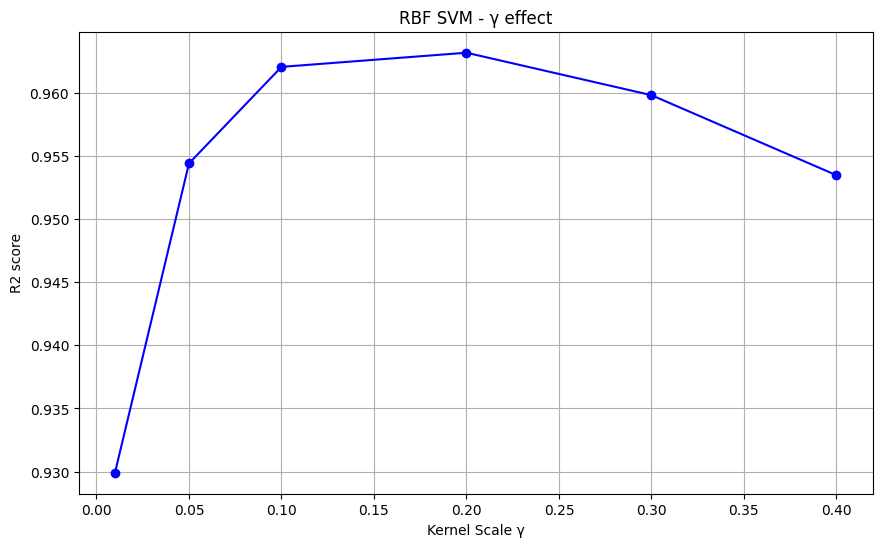

In [306]:
#Gamma vs R2 plot
plt.figure(figsize=(10.24,6.00))
plt.plot(Kernel_scale, R2_rec_gaus, marker='o', color='b')
plt.xlabel('Kernel Scale γ') 
plt.ylabel('R2 score')
plt.title("RBF SVM - γ effect")
plt.grid(True)
plt.savefig("task4_r2.png")

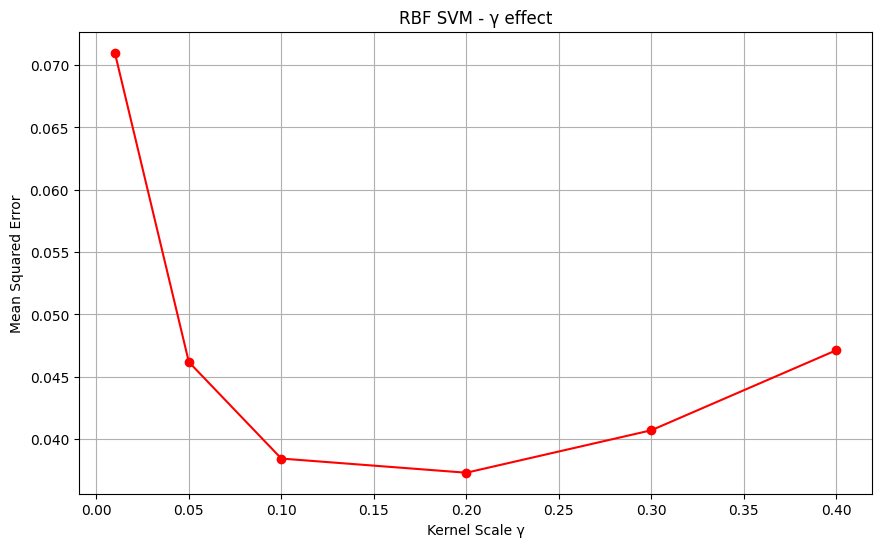

In [307]:
#Gamma vs MSE plot
plt.figure(figsize=(10.24,6.00))
plt.plot(Kernel_scale, MSE_rec_gaus, marker='o', color='r')
plt.xlabel('Kernel Scale γ') 
plt.ylabel('Mean Squared Error')
plt.title("RBF SVM - γ effect")
plt.grid(True)
plt.savefig("task4_mse.png")

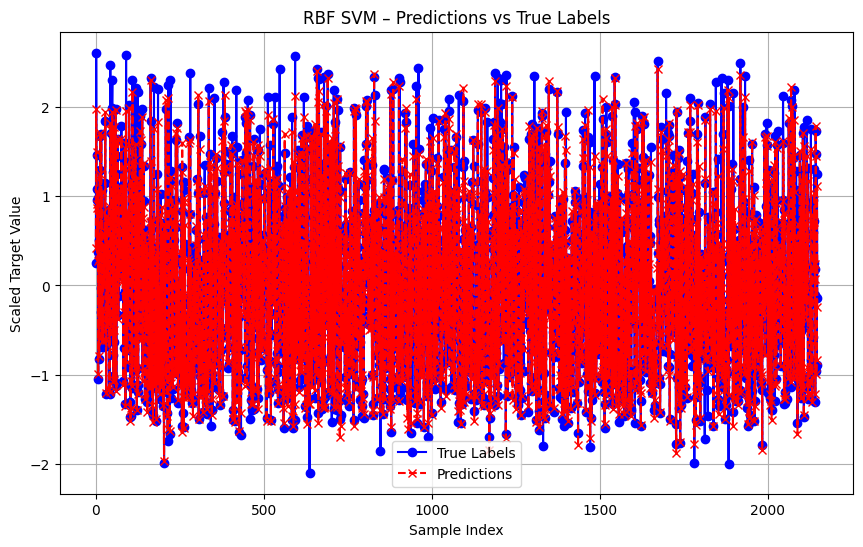

In [316]:
# Generate predictions from the best-performing Gaussian SVM model
y_pred_gaus = svm_gaus2.predict(X_test3)  # Use your final/best Gaussian SVM model

# Plot the predictions vs the true labels (y_test_s)
plt.figure(figsize=(10.24, 6.00))
plt.plot(y_test_s, label='True Labels', color='b', marker='o')  # True values
plt.plot(y_pred_gaus, label='Predictions', color='r', linestyle='--', marker='x')  # Predicted values

# Add labels and title
plt.xlabel('Sample Index')
plt.ylabel('Scaled Target Value')
plt.title('RBF SVM – Predictions vs True Labels')
plt.legend()  # Add legend to differentiate between true and predicted values
plt.grid(True)  # Add grid for better visualization
plt.savefig("task4_optional.png")

Optional: Find and tune the best SVM model for the regression problem, you can find better model than solution manual. Solution key R2=0.9762 & MSE=0.02406

In [309]:
# Define ranges for hyperparameter tuning
#C_values = [0.1, 1, 5, 10]  # You can fine-tune these further
#epsilon_values = [0.001, 0.01, 0.05]  # Smaller epsilon values might help
#gamma_values = ['scale', 0.01, 0.05, 0.1]  # Test 'scale' and custom gamma values

C_values = [18]  # Small increments around the best C value
epsilon_values = [0.015]  # Refining epsilon
gamma_values = [0.12] # Refining gamma

# Lists to store results
MSE_rec_gaus = []
R2_rec_gaus = []
best_MSE = float('inf')  # Initialize to a very large value
best_R2 = -float('inf')  # Initialize to a very small value
best_C, best_epsilon, best_gamma = None, None, None

# Loop through all combinations of C, epsilon, and gamma
for C in C_values:
    for epsilon in epsilon_values:
        for gamma in gamma_values:
            # Initialize the Gaussian (RBF) SVM with current C, epsilon, and gamma
            svm_gaus = SVR(kernel='rbf', C=C, epsilon=epsilon, gamma=gamma)
            
            # Train the model on the training data
            svm_gaus.fit(X_train3, y_train_s)
            
            # Evaluate the model on the test set
            MSE_svmgaus, R2_svmgaus = test_mymodel(svm_gaus, X_test3, y_test_s)
            
            # Store the performance metrics
            MSE_rec_gaus.append(MSE_svmgaus)
            R2_rec_gaus.append(R2_svmgaus)
            
            # Check if this combination gives a better result
            if R2_svmgaus > best_R2 and MSE_svmgaus < best_MSE:
                best_R2 = R2_svmgaus
                best_MSE = MSE_svmgaus
                best_C = C
                best_epsilon = epsilon
                best_gamma = gamma

# Output the best results
print(f"Best R² score: {best_R2:.5f} (C={best_C}, epsilon={best_epsilon}, gamma={best_gamma})")
print(f"Best MSE score: {best_MSE:.5f} (C={best_C}, epsilon={best_epsilon}, gamma={best_gamma})")

Best R² score: 0.97648 (C=18, epsilon=0.015, gamma=0.12)
Best MSE score: 0.02383 (C=18, epsilon=0.015, gamma=0.12)


In [310]:
#Gaussian SVM
#svm_gaus = ...
...
#MSE_svmgaus, R2_svmgaus= ...
#print("MSE scores of polynomial SVM: "+str(MSE_svmgaus))
#print("R2 scores of polynommial SVM: "+str(R2_svmgaus))

Ellipsis

#### Questions
<br>1) Write and compare results of default and tuned linear SVMs. 
<br>2) Write and compare results of auto and scaled gamma parameters for polynomial SVM. 
<br>3) Write and compare results of different gamma values for RBF SVM.
<br>4) Which model (with parameters) has the highest performance in load forecast problem? 


#### Bonus Task
In this bonus task you have to implement a regression model that predicts the total electricity consumption of a day using only time information in a categorical form.

<br>Some data types cannot be represented as numeric values like day of the month. Entering numeric value of the day can cause last weeks of the month have larger impact on prediction which may affect the prediction capability of many machine learning models. Each numeric value can be transformed into binary representation.

<br>For example, colour of apples 'red' and 'green' can be codded with 2 binary vectors a1 and a2 where a1 represents whether apple is red or not, a2 shows green or not with binary values 1 and 0. ( a1[55]=1 , 56th sample point is a red apple which requires a2[55]=0 because it cannot be both red and green at the same time.)
3 different categorical variables are used to model the time element. Matrix C has a shape of 8592*9. Each coloumn contains a specific categorical binary value. Order of columns in matrix C must be identical with the same order given below.
	<br>a)Weekend and weekday
	<br>b)Seasons: Winter, Spring, Summer, Fall
	<br>c)Hours: Day (07:00-16:00), Peak (17:00-21:00), Night (22:00-06:00)
<br>C=[Weekend,Weekday,Winter,..,Fall,Day,..,Night]

<br>For this task create a new feature matrix or vector X_bonus from the given Input CSV file that can only contain time related features. After that create the vector y_day which contains the total daily consumption level. Finally, create your regressor model, train, and evaluate the model performance. Provide your observations and findings. 


In [338]:
C = D["Categorical"]
print(C[1])
print(C.shape)

[0. 1. 1. 0. 0. 0. 0. 0. 1.]
(8592, 9)


In [342]:
data = pd.read_csv('Data.csv', delimiter=';')

time_features =  data[['day', 'month', 'hours']] # Only using time-related columns from the CSV
print(time_features)

      day  month  hours
0       1      1      0
1       1      1      1
2       1      1      2
3       1      1      3
4       1      1      4
...   ...    ...    ...
8755   31     12     19
8756   31     12     20
8757   31     12     21
8758   31     12     22
8759   31     12     23

[8760 rows x 3 columns]


In [343]:
# Day of the week for the first day of the year 2019 (Tuesday) is day 1 (too extra??)
time_features['day_of_week'] = (time_features['day'] + 1) % 7

time_features['is_weekend'] = np.where(time_features['day_of_week'] >= 5, 1, 0)  
time_features['is_weekday'] = np.where(time_features['day_of_week'] < 5, 1, 0)  

time_features['is_winter'] = np.where(time_features['month'].isin([12, 1, 2]), 1, 0)
time_features['is_spring'] = np.where(time_features['month'].isin([3, 4, 5]), 1, 0)
time_features['is_summer'] = np.where(time_features['month'].isin([6, 7, 8]), 1, 0)
time_features['is_fall'] = np.where(time_features['month'].isin([9, 10, 11]), 1, 0)

time_features['is_day'] = np.where((time_features['hours'] >= 7) & (time_features['hours'] <= 16), 1, 0)
time_features['is_peak'] = np.where((time_features['hours'] >= 17) & (time_features['hours'] <= 21), 1, 0)
time_features['is_night'] = np.where((time_features['hours'] >= 22) | (time_features['hours'] <= 6), 1, 0)

time_features_binary = time_features.drop(['day', 'month', 'hours','day_of_week'], axis=1)
#time_features_binary = time_features_binary[168:]
print(time_features_binary.shape)

print(time_features_binary.head(25))

(8760, 9)
    is_weekend  is_weekday  is_winter  is_spring  is_summer  is_fall  is_day  \
0            0           1          1          0          0        0       0   
1            0           1          1          0          0        0       0   
2            0           1          1          0          0        0       0   
3            0           1          1          0          0        0       0   
4            0           1          1          0          0        0       0   
5            0           1          1          0          0        0       0   
6            0           1          1          0          0        0       0   
7            0           1          1          0          0        0       1   
8            0           1          1          0          0        0       1   
9            0           1          1          0          0        0       1   
10           0           1          1          0          0        0       1   
11           0           1    

/var/folders/k8/4y401hn12tqg8hyrx_zfp3zw0000gn/T/ipykernel_5669/3258510469.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_features['day_of_week'] = (time_features['day'] + 1) % 7
/var/folders/k8/4y401hn12tqg8hyrx_zfp3zw0000gn/T/ipykernel_5669/3258510469.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_features['is_weekend'] = np.where(time_features['day_of_week'] >= 5, 1, 0)
/var/folders/k8/4y401hn12tqg8hyrx_zfp3zw0000gn/T/ipykernel_5669/3258510469.py:5: SettingWithCopyWarning: 
A value is

In [344]:
y_hourly = data['Actual load (MW)'].values  # Hourly consumption data
#y_hourly = y_hourly[168:]

y_day = y_hourly.reshape(-1, 24).sum(axis=1)  # total daily consumption
print(y_day.shape)

X_bonus_daily = time_features_binary.values.reshape(-1, 24, time_features_binary.shape[1])[:, 0, :]

X_train, X_test, y_train, y_test = train_test_split(X_bonus_daily, y_day, test_size=0.25, random_state=42)

regressor = SVR(kernel='rbf', C=16, epsilon=0.015, gamma=0.12) #best parameters
regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.4f}')
print(f'R² Score: {r2:.4f}')

(365,)
Mean Squared Error: 915990120.0677
R² Score: -0.1275


###### End of file - Ignore Remaining Cells ###### 